# Filter out tracks based on criteria

In [1]:
import pandas as pd 
import numpy as np 
import sys
import napari
import zarr
import dask.array as da
import os
import matplotlib.pyplot as plt

pythonPackagePath = os.path.abspath(r'C:\Users\Lab admin\Desktop\LLSM-CME-ANALYSIS\Final\src')
sys.path.append(pythonPackagePath)

from filters import Track, create_tracks_from_dataframe, drop_short_tracks
from filters import drop_early_peak_tracks, drop_last_frame_peak_tracks, drop_tracks_below_intensity
from filters import plot_z_sum, allocate_membrane_regions, plot_z_sum_bd

Do not change the code in the cell below 

In [2]:
base_dir = r'C:\Users\Lab admin\Desktop\u-track3D\testTrackability'
input_file_directory = 'controlOS_analysis/'

# # If a folder named 'datasets' doesn't exist in base_dir + input_file_directory, it will be created
# if not os.path.exists(os.path.join(base_dir, input_file_directory, 'datasets')):
#     os.makedirs(os.path.join(base_dir, input_file_directory, 'datasets'))

zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'
zarr_full_path = os.path.join(base_dir, zarr_file_directory)

input_directory = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'

# List which channel was used for detection and tracking
channel_detected = 3

output_directory = 'datasets'
output_file_name = 'filtered_tracks_final.pkl'
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)

In [3]:
# # This assumes that your notebook is inside 'Jupyter Notebooks', which is at the same level as 'test_data'
# base_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), '..', 'movie_data')

# zarr_directory = 'zarr_file/all_channels_data'
# zarr_full_path = os.path.join(base_dir, zarr_directory)

# input_directory = 'datasets'
# input_file_name = 'track_df_cleaned_final_full.pkl'
# input_directory_full = os.path.join(base_dir,input_directory, input_file_name)

# output_directory = 'datasets'
# output_file_name = 'filtered_tracks_final.pkl'
# output_directory_full = os.path.join(base_dir,output_directory, output_file_name)

In [3]:
# open tracks and movie
track_df = pd.read_pickle(input_directory)

z2 = zarr.open(zarr_full_path, mode='r')


## Set filtering parameters below

In [4]:
# Drop tracks shorter than this length (in frames)
threshold_length = 3 

# Drop tracks in which the peak intensity happens at or before this frame
peak_cutoff = 3 

# set this to false if you don't want to classify by apical, lateral, basal
membrane_regions_exist = True

# set default channel names (optionally adjust)

channel1_name = 'channel 1'
channel2_name = 'channel 2'
channel3_name = 'channel 3'


In [5]:
tracks = create_tracks_from_dataframe(df = track_df, intensities_col_name = ['c3_peak_mean', 'c2_peak_mean', 'c1_peak_mean'], 
track_id_col_name = 'track_id', frame_col_name = 'frame', coords = ['mu_x', 'mu_y', 'mu_z'])

In [6]:
# Create DataFrame from Track instances
tracks_data = {
    'mu_x': [track.x for track in tracks],
    'mu_y': [track.y for track in tracks],
    'mu_z': [track.z for track in tracks],
    'track_id': [track.track_id.values[0] for track in tracks],
    'track_length': [track.track_length for track in tracks],
    'track_start': [track.track_start for track in tracks],
    'track_end': [track.track_end for track in tracks],
    'c3_peak': [track.peak_intensities[0] for track in tracks],
    'c2_peak': [track.peak_intensities[1] for track in tracks],
    'c1_peak': [track.peak_intensities[2] for track in tracks],
    'c3_peak_frame': [track.peak_intensity_frames[0] for track in tracks],
    'c2_peak_frame': [track.peak_intensity_frames[1] for track in tracks],
    'c1_peak_frame': [track.peak_intensity_frames[2] for track in tracks],
    'mean_displacement': [track.mean_displacement_track for track in tracks],
    'mean_z': [track.mean_z_value for track in tracks],
    'mean_z_displacement': [track.mean_z_displacement for track in tracks], 
    'max_radius_from_origin': [track.max_radius_from_origin for track in tracks], 
    'max_distance_between_two_points': [track.max_distance_between_two_points for track in tracks], 
    'C3_adjusted_voxel_sum': [track.adjusted_voxel_sum_c3 for track in tracks],
    'C2_adjusted_voxel_sum': [track.adjusted_voxel_sum_c2 for track in tracks],
    'C1_adjusted_voxel_sum': [track.adjusted_voxel_sum_c1 for track in tracks],
    'C3_adjusted_voxel_sum_peak': [track.peak_adjusted_voxel_sum[0] for track in tracks],
    'C2_adjusted_voxel_sum_peak': [track.peak_adjusted_voxel_sum[1] for track in tracks],
    'C1_adjusted_voxel_sum_peak': [track.peak_adjusted_voxel_sum[2] for track in tracks],
    'C3_adjusted_voxel_sum_peak_frame': [track.peak_adjusted_voxel_sum_frame[0] for track in tracks],
    'C2_adjusted_voxel_sum_peak_frame': [track.peak_adjusted_voxel_sum_frame[1] for track in tracks],
    'C1_adjusted_voxel_sum_peak_frame': [track.peak_adjusted_voxel_sum_frame[2] for track in tracks],
    'max_z_movement': [track.max_z_movement for track in tracks],
    'max_y_movement': [track.max_y_movement for track in tracks],
    'max_x_movement': [track.max_x_movement for track in tracks],
}

tracks_df = pd.DataFrame(tracks_data)

Filter out tracks based on length and completeness

In [7]:
#dropping tracks of length 3 and below
length_filtered_tracks_df = drop_short_tracks(df = tracks_df, threshold = threshold_length)

# Drop incomplete tracks (starting at first frame or ending at last frame)
incomplete_tracks_df = tracks_df.loc[(tracks_df['track_start'] == 0) | (tracks_df['track_end'] == track_df['frame'].max())]
tracks_df_incomplete = tracks_df.drop(incomplete_tracks_df.index)


### Determining Valid Channel 3 tracks 
valid_c3_tracks will serve as baseline "clathrin positive" and valid tracks

In [8]:
### Dropping tracks with Channel 3 peak in the last frame
# valid_c3_tracks = drop_last_frame_peak_tracks(df = length_filtered_tracks_df, intensity_col = 'c3_peak_frame')
valid_c3_tracks = drop_last_frame_peak_tracks(df = length_filtered_tracks_df, intensity_col = 'C3_adjusted_voxel_sum_peak_frame')

### Dropping tracks with Channel 3 which have their peaks in the first three frames 
# valid_c3_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'c3_peak_frame',
#                                       cutoff = peak_cutoff)
valid_c3_tracks = drop_early_peak_tracks(df = valid_c3_tracks, intensity_peak_frame = 'C3_adjusted_voxel_sum_peak_frame',
                                      cutoff = peak_cutoff)

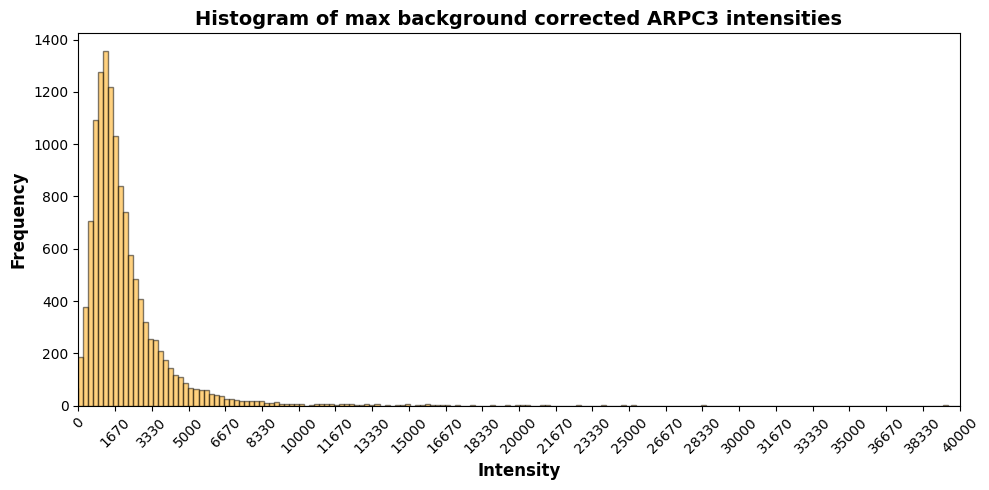

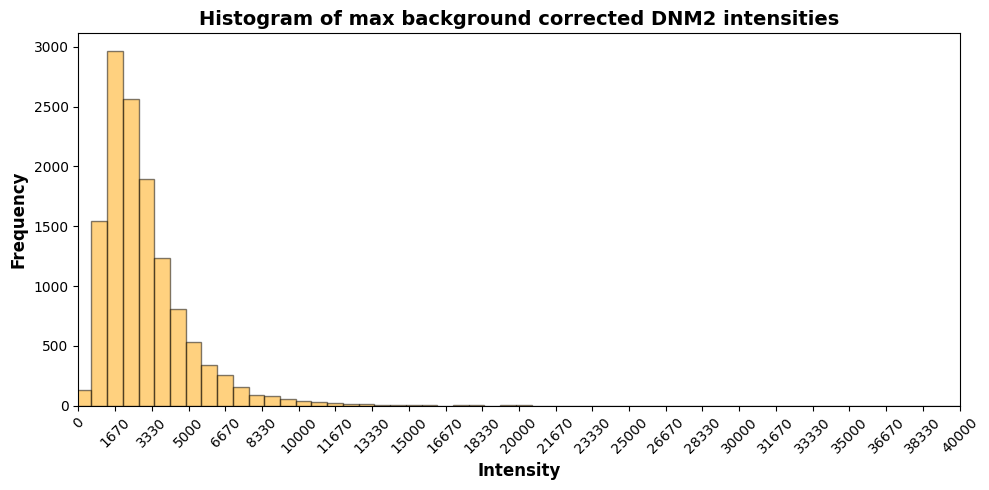

In [9]:
# Histogram of maximum background corrected ARPC3 intensity values, to determine cutoff for ARPC3-positive tracks
columns = ['C1_adjusted_voxel_sum_peak', 'C2_adjusted_voxel_sum_peak']
marker = ['ARPC3', 'DNM2']

# # Max AP2 intensity per track
# control_AP2 = tracks_channel_subset_control['C3_adjusted_voxel_sum'].reset_index(drop=True)

# max_control_AP2 = []
# for j in range(len(control_AP2)):
#     max_control_AP2.append(max(control_AP2[j]))  

for i in range(len(columns)):
    # Create a figure with 2 subplots side by side
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

    control =  valid_c3_tracks[columns[i]].reset_index(drop=True)
    

    max_control = []
    for j in range(len(control)):
        max_control.append(control[j])  # For every element in arpc3_control, get the max value



    # # Normalize to max AP2 intensity, optional
    # max_control = (np.array(max_control) / np.array(max_control_AP2)).tolist()
    


    # Generate 50 equally spaced bins between the min and max of max_arpc3_control and max_arpc3_OS
    # so I can plot the histograms of max_arpc3_control and max_arpc3_OS on the same plot
    # with the same binning
    bins = np.linspace(min(max_control), max(max_control), 200)


    # Plot histogram on the first subplot
    ax1.hist(max_control, bins=bins, color='orange', edgecolor='black', alpha=0.5, label='Control')

    # Calculate the data range
    # x_min = min(max_control)
    # x_max = max(max_control)
    x_min = 0
    x_max = 40000
    
    # Round minimum down and maximum up to nearest 10
    x_min_rounded = np.floor(x_min / 10) * 10
    x_max_rounded = np.ceil(x_max / 10) * 10
    
    # Create tick marks rounded to the nearest 10
    num_ticks =25  # Adjust this number for more or fewer ticks
    
    # Generate ticks rounded to the nearest 10
    x_ticks = np.linspace(x_min_rounded, x_max_rounded, num_ticks)
    x_ticks_rounded = np.round(x_ticks / 10) * 10  # Round to nearest 10
    
    ax1.set_xticks(x_ticks_rounded)
    ax1.set_xticklabels([f'{int(x)}' for x in x_ticks_rounded], rotation=45, fontsize=10)
    
    ax1.set_xlabel('Intensity', fontsize=12, weight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
    ax1.set_title('Histogram of max background corrected' + ' ' + marker[i] + ' ' +  'intensities', fontsize=14, weight='bold')

    # set x limit to 0 and 20000
    ax1.set_xlim(x_min_rounded, x_max_rounded)

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [10]:
valid_c3_tracks_filter = valid_c3_tracks[valid_c3_tracks['C1_adjusted_voxel_sum_peak'] > 4000]

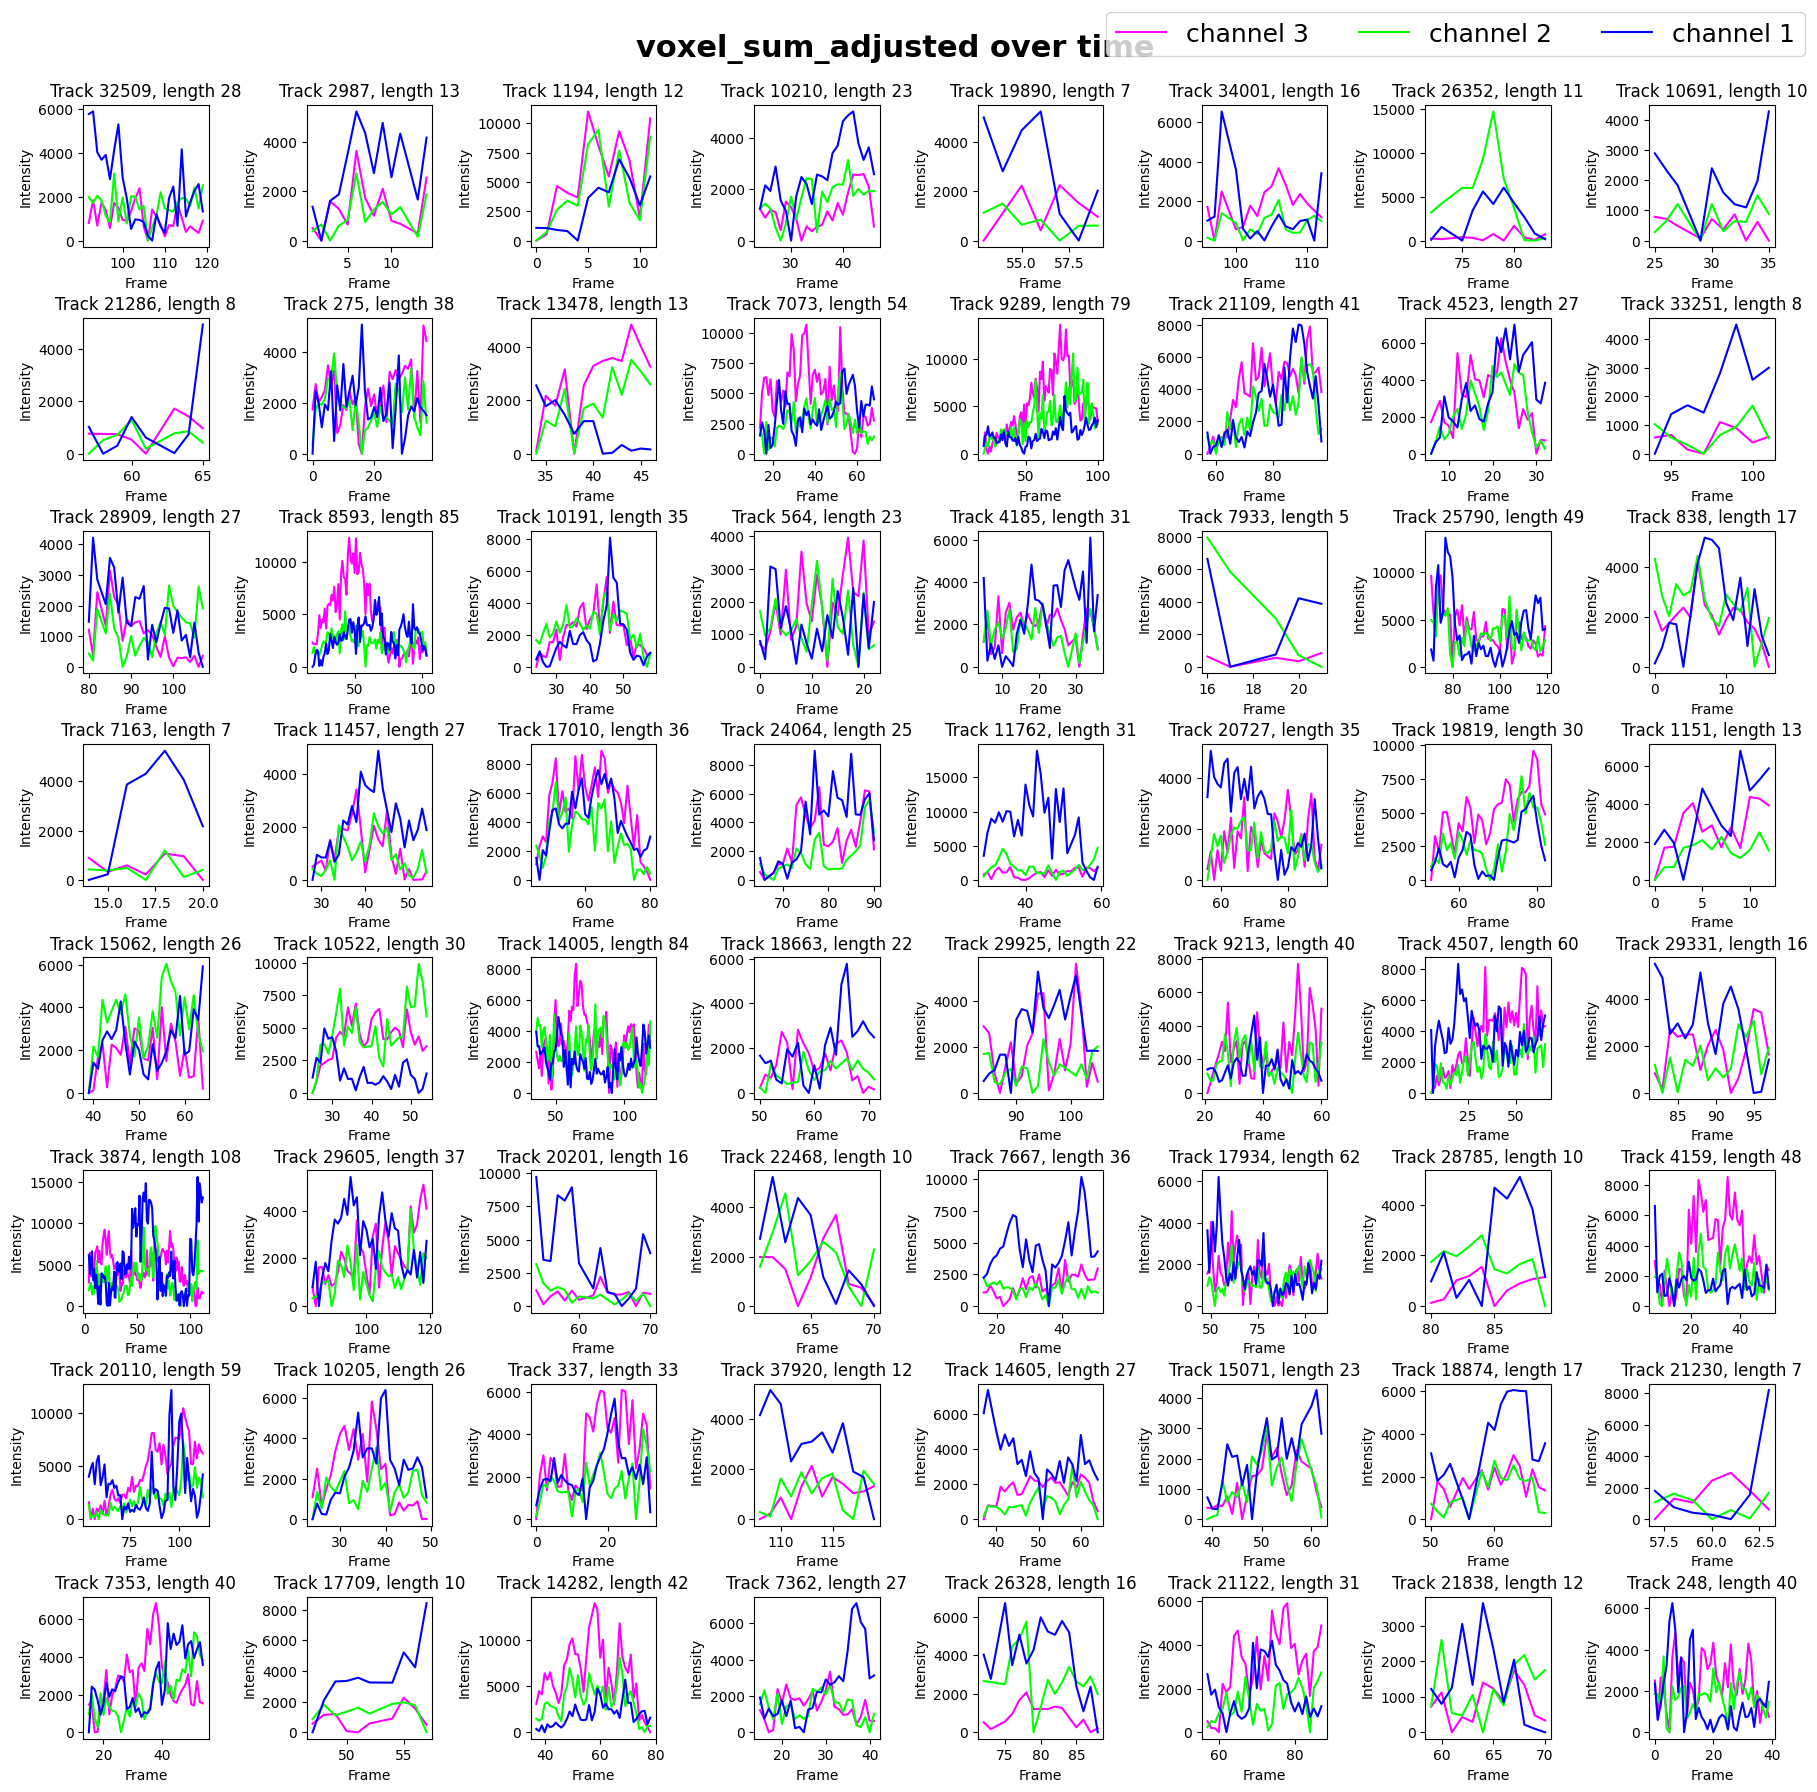

In [11]:
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax
value_to_plot = 'voxel_sum_adjusted'

# set 'normalized = False' to plot raw intensities

random_tracks = random_track_ids(dataframe = valid_c3_tracks_filter, desired_length = [0, np.inf], 
                                 track_length_col_name = 'track_length', track_id_col_name = 'track_id', 
                                num_to_select = 64)

intensity_time_plot(dataframe = track_df, tracks_to_plot = random_tracks, 
intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 3, legend_values = [channel3_name, channel2_name, channel1_name],
line_colors = ['magenta', 'lime', 'blue'], graph_title = f'{value_to_plot}', normalized=False)

In [12]:
# This is the minimum intensity value that a specific channel within a track must achieve to be considered positive for that channel.
threshold_intensity_channel_1 = 2500
threshold_intensity_channel_2 = 2500

### Filtering for Channel 2 
dnm2_positive_tracks will serve as the baseline for dynamin positive tracks

In [13]:
# Channel 2-positive tracks

# dnm2_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_2, 
#                                           intensity_peak_frame = 'c2_peak')

dnm2_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_2, 
                                          intensity_peak_frame = 'C2_adjusted_voxel_sum_peak')

### Filter tracks based on channel 2 peak if occurs within 3 frames of starting of a track 

# dnm2_positive_tracks = drop_early_peak_tracks(df = dnm2_positive_tracks, intensity_peak_frame = 'c2_peak_frame', 
#                                       cutoff = peak_cutoff)

dnm2_positive_tracks = drop_early_peak_tracks(df = dnm2_positive_tracks, intensity_peak_frame = 'C2_adjusted_voxel_sum_peak_frame', 
                                      cutoff = peak_cutoff)

### Filter tracks based on channel 2 peaks occuring in the last frame 

# dnm2_positive_tracks = drop_last_frame_peak_tracks(df = dnm2_positive_tracks, intensity_col = 'c2_peak_frame')

dnm2_positive_tracks = drop_last_frame_peak_tracks(df = dnm2_positive_tracks, intensity_col = 'C2_adjusted_voxel_sum_peak_frame')
dnm2_positive_tracks.shape

(5237, 30)

### Identifying Channel 1 positive tracks 

In [14]:
### Identifying Actin Positive Tracks 
# actin_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_1, 
#                                           intensity_peak_frame = 'c1_peak' )

actin_positive_tracks = drop_tracks_below_intensity(df = valid_c3_tracks, threshold = threshold_intensity_channel_1, 
                                          intensity_peak_frame = 'C1_adjusted_voxel_sum_peak' )

### Filter tracks based on channel 1 peaks if occurs within the first 3 frames 

# actin_positive_tracks = drop_early_peak_tracks(df = actin_positive_tracks, intensity_peak_frame = 'c1_peak_frame', 
#                                       cutoff = peak_cutoff)

actin_positive_tracks = drop_early_peak_tracks(df = actin_positive_tracks, intensity_peak_frame = 'C1_adjusted_voxel_sum_peak_frame', 
                                      cutoff = peak_cutoff)

# actin_positive_tracks = drop_last_frame_peak_tracks(df = actin_positive_tracks, intensity_col = 'c1_peak_frame')

actin_positive_tracks = drop_last_frame_peak_tracks(df = actin_positive_tracks, intensity_col = 'C1_adjusted_voxel_sum_peak_frame')

Combining actin and dynamin positive tracks with valid clathrin positive tracks 

In [15]:
final_tracks = valid_c3_tracks.copy(deep = True)
final_tracks['channel2_positive'] = False 
final_tracks['channel1_positive'] = False 

In [16]:
# ***Setting actin positive tracks to True***

# Get the track IDs from actin_positive_tracks
actin_positive_track_ids = actin_positive_tracks['track_id']

# Set 'actin_positive' to True for rows where 'track_id' is in positive_track_ids
final_tracks.loc[final_tracks['track_id'].isin(actin_positive_track_ids), 'channel1_positive'] = True

actin_rows_count = final_tracks[final_tracks['channel1_positive'] == True].shape[0]
print(f'number of {channel1_name} positive tracks are: {actin_rows_count}')

# ***Setting dynamin positive tracks to True***

# Get the track IDs from actin_positive_tracks
dnm2_positive_track_ids = dnm2_positive_tracks['track_id']

# Set 'actin_positive' to True for rows where 'track_id' is in positive_track_ids
final_tracks.loc[final_tracks['track_id'].isin(dnm2_positive_track_ids), 'channel2_positive'] = True

dnm2_rows_count = final_tracks[final_tracks['channel2_positive'] == True].shape[0]
print(f'number of {channel2_name} positive tracks are: {dnm2_rows_count}')


actin_dnm2_rows_count = final_tracks[(final_tracks['channel2_positive'] == True) & 
                                     (final_tracks['channel1_positive'] == True)].shape[0]
print(f"number of {channel1_name} and {channel2_name} positive tracks are: {actin_dnm2_rows_count}")

number of channel 1 positive tracks are: 2328
number of channel 2 positive tracks are: 5237
number of channel 1 and channel 2 positive tracks are: 1487


### Estimating Apical/Basal/Lateral boundaries of cell
Based on the slices with the most intensity in channel 1

In [18]:
import importlib
import filters
importlib.reload(filters)

<module 'filters' from 'C:\\Users\\Lab admin\\Desktop\\LLSM-CME-ANALYSIS\\Final\\src\\filters.py'>

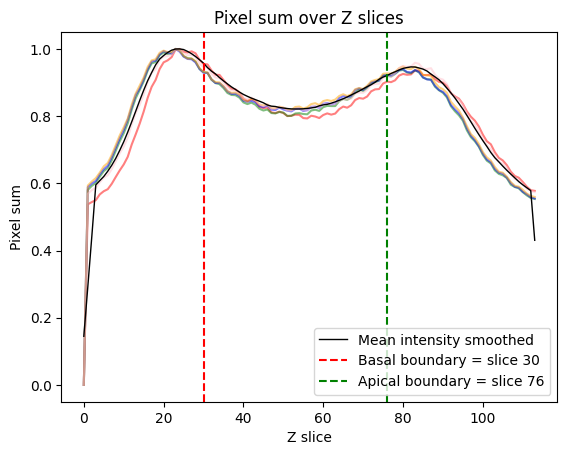

In [19]:
#channel is hard coded in the function right now. Need to allow it to be passed as a parameter by the user 
if membrane_regions_exist == True:      
    boundaries = plot_z_sum_bd(z2)

This Z axis plot shows where the max intensities are, which roughly correspond to the basal and apical regions of the cell.

The lines are the auto-detected boundaries between basal, lateral, and apical.  

If needed, you can scan through the z series in Napari below to adjust the position of these boundaries.

In [20]:
# If ychange the values of the boundaries to the ones you want to use

basal_lateral_boundary_slice_manual = []
lateral_apical_boundary_slice_manual = []

if membrane_regions_exist == True and basal_lateral_boundary_slice_manual:
    boundaries = [basal_lateral_boundary_slice_manual, lateral_apical_boundary_slice_manual]
    print('Manual basal-lateral boundary slice is:', basal_lateral_boundary_slice_manual)   
    print('Manual lateral-apical boundary slice is:', lateral_apical_boundary_slice_manual)

else:
    print('Basal-lateral boundary slice is:', boundaries[0])   
    print('Lateral-apical boundary slice is:', boundaries[1])  




Basal-lateral boundary slice is: 30
Lateral-apical boundary slice is: 76


In [ ]:
if membrane_regions_exist == True: 
    allocate_membrane_regions(df = final_tracks, basal_range = [0,25] , lateral_range = [25,75], apical_range = [75,112])

else: 
    final_tracks['membrane_region'] = 'Basal'

In [22]:
# # Subset final tracks such that 25 is less than mean_z less than 30
# final_tracks[(final_tracks['mean_z'] > 25) & (final_tracks['mean_z'] < 30)][['mean_z', 'membrane_region']]
final_tracks.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,C1_adjusted_voxel_sum_peak,C3_adjusted_voxel_sum_peak_frame,C2_adjusted_voxel_sum_peak_frame,C1_adjusted_voxel_sum_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive,membrane_region
0,0 64.0 5232 63.0 7186 63.0 1...,0 699.0 5232 698.0 7186 698....,0 22.0 5232 22.0 7186 22.0 1...,0,120,0,119,290.062857,311.925714,377.742857,...,12133.947368,34,5,108,6.0,12.0,16.0,True,True,Basal
1,2915 63.0 5418 63.0 7144 63.0 1...,2915 418.0 5418 418.0 7144 418....,2915 31.0 5418 31.0 7144 31.0 1...,1,120,0,119,256.114286,262.269231,282.954286,...,1891.196507,70,71,7,5.0,5.0,4.0,True,False,Lateral
2,2905 70.0 4956 70.0 7323 70.0 1...,2905 925.0 4956 925.0 7323 926....,2905 35.0 4956 35.0 7323 35.0 1...,2,120,0,119,272.370588,215.268571,337.748387,...,3038.743590,50,50,51,8.0,8.0,4.0,True,True,Lateral
3,2908 81.0 5616 81.0 6916 81.0 1...,2908 1987.0 5616 1987.0 6916 19...,2908 39.0 5616 38.0 6916 38.0 1...,3,120,0,119,200.645714,202.051429,191.594286,...,2894.789474,51,3,51,7.0,3.0,4.0,False,True,Lateral
4,2894 146.0 6053 145.0 6918 145....,2894 1422.0 6053 1423.0 6918 14...,2894 47.0 6053 47.0 6918 47.0 9...,4,120,0,119,268.171429,267.320000,253.640000,...,4686.736842,20,103,99,9.0,6.0,7.0,True,True,Lateral


Save tracks

In [23]:
final_tracks.to_pickle(output_directory_full)

# Visualize tracks in Napari to assess track filtering quality

In [24]:
# Report number of frames and a random color per track

import random

# Calculate the number of unique frames for each track and create a mapping from track_id to number_of_frames
frame_counts = track_df.groupby('track_id')['frame'].nunique().to_dict()

# Map the frame counts to the original dataframe, creating a new column
track_df['number_of_frames'] = track_df['track_id'].map(frame_counts)

# Assuming 'track_df' is your DataFrame
track_ids = track_df['track_id'].unique().tolist()

# Generate a list of random colors
colors = [random.randint(0, 255) for _ in range(len(track_ids))]

# Create a dictionary that maps each track id to a random color
color_dict = dict(zip(track_ids, colors))

# Now you can use this dictionary to assign colors to the tracks
track_df['color'] = track_df['track_id'].map(color_dict)

# Sort track_df by frame and track_id
track_df = track_df.sort_values(by=['frame', 'track_id']).reset_index(drop=True)

track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,segment_id,sigma_z,sigma_y,sigma_x,...,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg,number_of_frames,color
0,0,64.0,699.0,22.0,482.0,0,NaN,3,2,2,...,482,41960,11223.157895,63,698,21,175,441,120,28
1,0,63.0,418.0,31.0,335.0,1,NaN,3,2,2,...,335,27926,5044.055556,62,417,31,175,427,120,67
2,0,70.0,925.0,35.0,354.0,2,NaN,3,2,2,...,354,27593,4583.277778,69,924,34,175,427,120,86
3,0,81.0,1987.0,39.0,348.0,3,NaN,3,2,2,...,348,30215,6090.000000,80,1986,38,175,441,120,109
4,0,146.0,1422.0,47.0,398.0,4,NaN,3,2,2,...,398,30410,7132.368421,146,1421,46,175,441,120,139


In [25]:
# # Create a napari viewer
# viewer = napari.Viewer()

# #access channel 3 only from zarr array 
# dask_array = da.from_zarr(z2)

# #the axis arrangement is (t,c,z,y,x)
# #for the sake of improved performance only 1 channel could be imported here (if images get super large and performance issues occur)
# all_channels = dask_array[:,:,:,:,:]

# # # Calculate the 1st and 99th percentiles for the 10th time point
# # lower_limit_1, upper_limit_1 = da.percentile(all_channels[10,0,:,:,:].ravel(), [5, 95]).compute()
# # lower_limit_2, upper_limit_2 = da.percentile(all_channels[10,1,:,:,:].ravel(), [5, 95]).compute()
# # lower_limit_3, upper_limit_3 = da.percentile(all_channels[10,2,:,:,:].ravel(), [5, 95]).compute()


# # # Set the contrast limits

# # # Add each channel as a separate image layer with its own contrast limits
# # layer_raw_1 = viewer.add_image(all_channels[0], contrast_limits=[lower_limit_1, upper_limit_1], name='channel 1', colormap='yellow')
# # layer_raw_2 = viewer.add_image(all_channels[1], contrast_limits=[lower_limit_2, upper_limit_2], name='channel 2', colormap = 'cyan')
# # layer_raw_3 = viewer.add_image(all_channels[2], contrast_limits=[lower_limit_3, upper_limit_3], name='channel 3', colormap = 'magenta')

# # Add the 4D stack to the viewer
# layer_raw = viewer.add_image(all_channels, channel_axis = 1, name = ['channel 1', 'channel 2', 'channel 3'])
# #other useful parameters 
# #color_map = list
# #contrast_limits = list of list 

# track_properties = {'number_of_frames': track_df['number_of_frames'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}
# # track_properties = {'number_of_frames': track_df['track_length'].to_numpy(), 'track_id_rand': track_df['color'].to_numpy()}


# # viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks')

# tracks_layer = viewer.add_tracks(track_df[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all tracks', properties=track_properties, color_by='track_id_rand', tail_length = 15, tail_width = 2, colormap = 'hsv')

# # Add Bounding Box
# layer_raw[0].bounding_box.visible = True
# layer_raw[1].bounding_box.visible = True
# layer_raw[2].bounding_box.visible = True


In [26]:
# #Displaying Dynamin Positive tracks only (Tracks where actin is not present)
# dnm2_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == True) & (final_tracks['channel1_positive'] == False)]
# dnm2_tracks_list = dnm2_positive_tracks_df['track_id'].values
# track_1 = track_df[track_df['track_id'].isin(dnm2_tracks_list)]
# viewer.add_tracks(track_1[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'channel2+ tracks')

In [27]:
# #Displaying Actin Positive tracks only (Tracks where Dynamin is not present)
# actin_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == False) & (final_tracks['channel1_positive'] == True)]
# actin_tracks_list = actin_positive_tracks_df['track_id'].values
# track_2 = track_df[track_df['track_id'].isin(actin_tracks_list)]
# viewer.add_tracks(track_2[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'channel1+ tracks')

In [28]:
# #Displaying all 3 channels positive tracks 
# all_positive_tracks_df = final_tracks[(final_tracks['channel2_positive'] == True) & (final_tracks['channel1_positive'] == True)]
# all_positive_tracks_list = all_positive_tracks_df['track_id'].values
# track_3 = track_df[track_df['track_id'].isin(all_positive_tracks_list)]
# viewer.add_tracks(track_3[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'all+ tracks')

In [29]:
# #Displaying basal tracks 
# if membrane_regions_exist == True: 
#     basal_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Basal']
#     basal_tracks_list = basal_tracks_df['track_id'].values
#     track_4 = track_df[track_df['track_id'].isin(basal_tracks_list)]
#     viewer.add_tracks(track_4[["track_id", "frame","c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'basal tracks')

In [30]:
# #Displaying lateral tracks 
# if membrane_regions_exist == True:
#     lateral_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Lateral']
#     lateral_tracks_list = lateral_tracks_df['track_id'].values
#     track_5 = track_df[track_df['track_id'].isin(lateral_tracks_list)]
#     viewer.add_tracks(track_5[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Lateral tracks')

In [31]:
# #Displaying apical tracks 
# if membrane_regions_exist == True:
#     apical_tracks_df = final_tracks[final_tracks['membrane_region'] == 'Apical']
#     apical_tracks_list = apical_tracks_df['track_id'].values
#     track_6 = track_df[track_df['track_id'].isin(apical_tracks_list)]
#     viewer.add_tracks(track_6[["track_id", "frame", "c3_peak_z", "c3_peak_y", "c3_peak_x"]], name = 'Apical tracks')

### final_tracks dataframe stores tracks which are at least positive in the channel you tracked.

## Once you have performed this step and have filtered tracks  you can now use the dashboard to test performance of the pipeline and access visualisations. 

# Go to multipage_dashboard and run app.py 